In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

final_labels = pd.read_csv("final_labels.csv")

In [17]:
final_labels.head()

,Unnamed: 0,model,bank,label,confidence
0,0,dalle,BofA,1,0.996932
1,1,dalle,BofA,0,0.991670
2,2,dalle,BofA,0,0.971974
3,3,dalle,BofA,0,0.992670
4,4,dalle,BofA,0,0.953453


In [18]:
final_labels.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 283 entries, 0 to 282
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  283 non-null    int64  
 1   model       283 non-null    object 
 2   bank        283 non-null    object 
 3   label       283 non-null    int64  
 4   confidence  283 non-null    float64
dtypes: float64(1), int64(2), object(2)
memory usage: 11.2+ KB


In [19]:
final_labels.describe()

,Unnamed: 0,label,confidence
count,283.000000,283.000000,283.000000
mean,160.130742,0.243816,0.968528
std,96.812683,0.430144,0.039397
min,0.000000,0.000000,0.850886
25%,74.500000,0.000000,0.963678
50%,159.000000,0.000000,0.985949
75%,249.500000,0.000000,0.993749
max,322.000000,1.000000,0.999462


univariable distributions

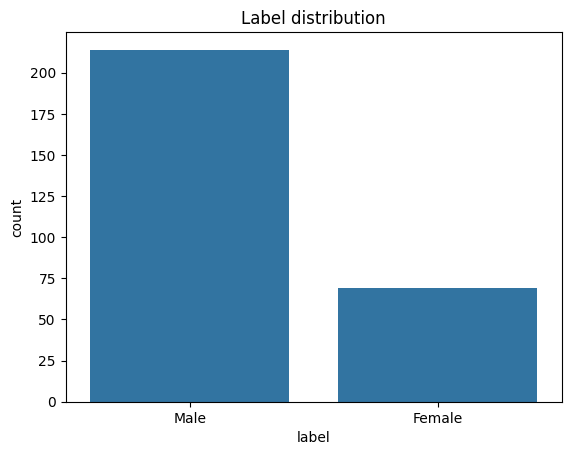

In [20]:
sns.countplot(x="label", data=final_labels)
plt.title("Label distribution")
plt.xticks(
    ticks=[0, 1],
    labels=["Male", "Female"]
)
plt.show()

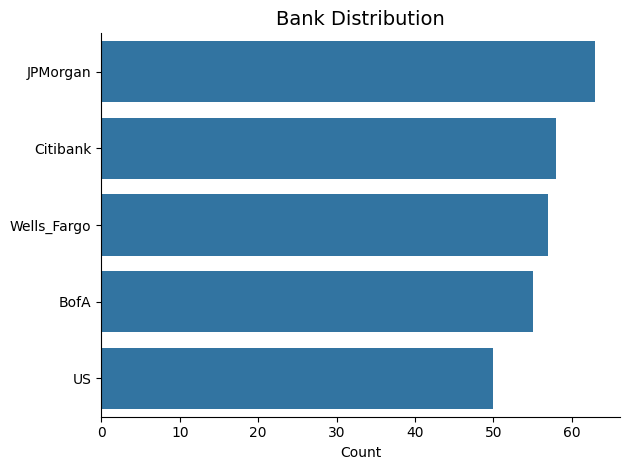

In [21]:
sns.countplot(
    y="bank",
    data=final_labels,
    order=final_labels["bank"].value_counts().index,
)

plt.title("Bank Distribution", fontsize=14)
plt.xlabel("Count")
plt.ylabel("")

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

plt.show()


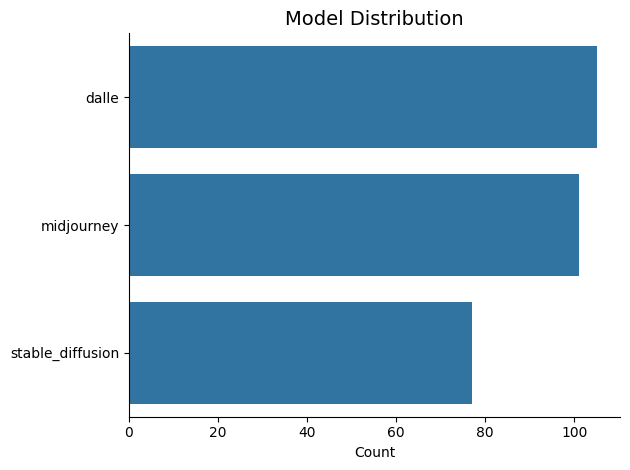

In [22]:
sns.countplot(
    y="model",
    data=final_labels,
    order=final_labels["model"].value_counts().index,
)

plt.title("Model Distribution", fontsize=14)
plt.xlabel("Count")
plt.ylabel("")

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

plt.show()


distribution per model

In [23]:
model_counts = (
    final_labels
    .groupby(['model', 'label'])
    .size()
    .unstack(fill_value=0)
)

model_counts.columns = ['Male (0)', 'Female (1)']
print(model_counts)


                  Male (0)  Female (1)
model                                 
dalle                   76          29
midjourney              90          11
stable_diffusion        48          29


In [24]:
model_props = model_counts.div(model_counts.sum(axis=1), axis=0)
print(model_props)


                  Male (0)  Female (1)
model                                 
dalle             0.723810    0.276190
midjourney        0.891089    0.108911
stable_diffusion  0.623377    0.376623


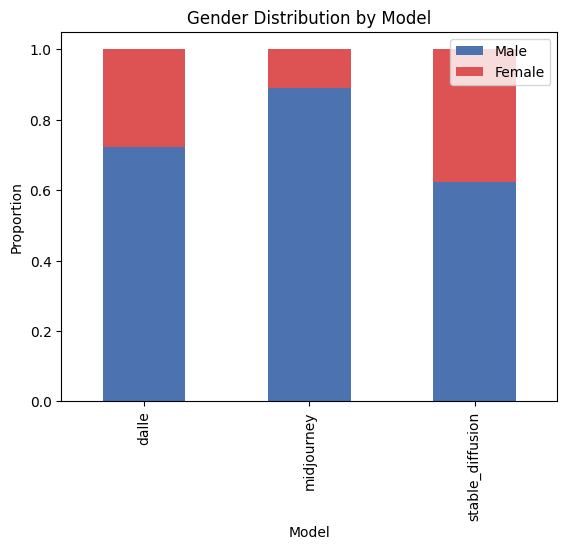

In [25]:
model_props.plot(kind='bar', stacked=True, color=['#4C72B0', "#DD5252"])

plt.title("Gender Distribution by Model")
plt.ylabel("Proportion")
plt.xlabel("Model")
plt.legend(["Male", "Female"])
plt.show()


Distribution per Bank

In [26]:
bank_counts = (
    final_labels
    .groupby(['bank', 'label'])
    .size()
    .unstack(fill_value=0)
)

bank_props = bank_counts.div(bank_counts.sum(axis=1), axis=0)

print(bank_props)


label               0         1
bank                           
BofA         0.781818  0.218182
Citibank     0.741379  0.258621
JPMorgan     0.825397  0.174603
US           0.740000  0.260000
Wells_Fargo  0.684211  0.315789


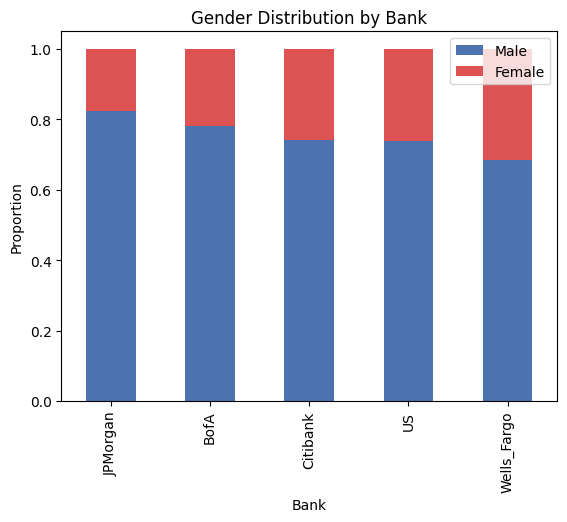

In [27]:
profession_props_sorted = bank_props.sort_values(by=1)

profession_props_sorted.plot(kind='bar', stacked=True, color=['#4C72B0', "#DD5252"])

plt.title("Gender Distribution by Bank")
plt.ylabel("Proportion")
plt.xlabel("Bank")
plt.legend(["Male", "Female"])
plt.show()


Distribution per Model × Profession

In [28]:
model_bank_counts = (
    final_labels
    .groupby(['model', 'bank', 'label'])
    .size()
    .unstack(fill_value=0)
)

model_bank_props = (
    model_bank_counts
    .div(model_bank_counts.sum(axis=1), axis=0)
)

print(model_bank_props)


label                                0         1
model            bank                           
dalle            BofA         0.700000  0.300000
                 Citibank     0.714286  0.285714
                 JPMorgan     0.809524  0.190476
                 US           0.727273  0.272727
                 Wells_Fargo  0.666667  0.333333
midjourney       BofA         0.950000  0.050000
                 Citibank     0.941176  0.058824
                 JPMorgan     0.931034  0.068966
                 US           0.846154  0.153846
                 Wells_Fargo  0.772727  0.227273
stable_diffusion BofA         0.666667  0.333333
                 Citibank     0.600000  0.400000
                 JPMorgan     0.615385  0.384615
                 US           0.666667  0.333333
                 Wells_Fargo  0.571429  0.428571


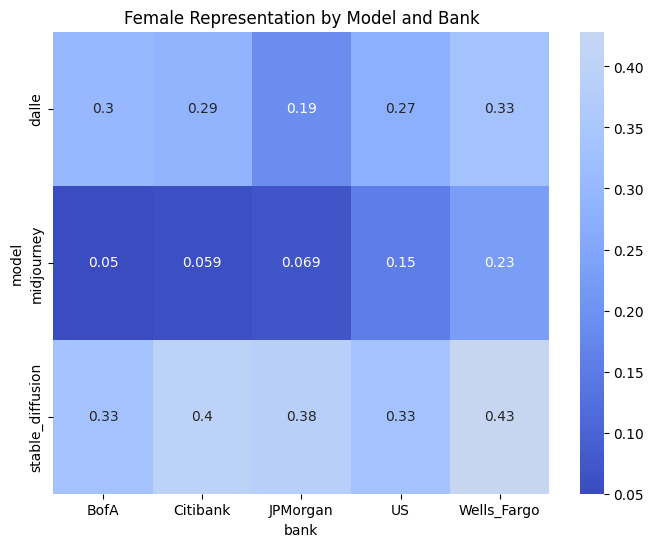

In [29]:
female_props = model_bank_props[1].unstack()

plt.figure(figsize=(8,6))
sns.heatmap(female_props, annot=True, cmap="coolwarm", center=0.5)

plt.title("Female Representation by Model and Bank")
plt.show()


sanity checks

In [30]:
print(final_labels['label'].value_counts())
print(final_labels.groupby('model').size())
print(final_labels.groupby('bank').size())


label
0    214
1     69
Name: count, dtype: int64
model
dalle               105
midjourney          101
stable_diffusion     77
dtype: int64
bank
BofA           55
Citibank       58
JPMorgan       63
US             50
Wells_Fargo    57
dtype: int64
